In [1]:
# importing necessary  library
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras


2025-03-28 10:49:39.064213: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# # # !pip install pandas-datareader
# !pip install pandas==1.5.3



In [3]:
### Data Collection
import pandas_datareader as pdr
key="ee0553bcc7a6645723d1bfd8f865d881262d7c8d"

In [4]:
df = pdr.get_data_tiingo('AAPL', api_key=key)

/var/folders/xc/2sw1p49174924vg6v0vhtq8c0000gn/T/ipykernel_56932/1593133401.py:1: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  df = pdr.get_data_tiingo('AAPL', api_key=key)


In [9]:
df.to_csv('AAPL.csv')

In [11]:
df=pd.read_csv('AAPL.csv')

In [13]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2020-03-30 00:00:00+00:00,254.81,255.52,249.40,250.74,41994110,61.840225,62.012536,60.527264,60.852470,167976440,0.0,1.0
1,AAPL,2020-03-31 00:00:00+00:00,254.29,262.49,252.00,255.60,49250501,61.714025,63.704095,61.158262,62.031951,197002004,0.0,1.0
2,AAPL,2020-04-01 00:00:00+00:00,240.91,248.72,239.13,246.50,44054638,58.466813,60.362233,58.034822,59.823458,176218552,0.0,1.0
3,AAPL,2020-04-02 00:00:00+00:00,244.93,245.15,236.90,240.34,41483493,59.442432,59.495825,57.493620,58.328478,165933972,0.0,1.0
4,AAPL,2020-04-03 00:00:00+00:00,241.41,245.70,238.97,242.80,32470017,58.588158,59.629305,57.995991,58.925500,129880068,0.0,1.0


In [15]:
df1=df.reset_index()['close']

In [17]:
df1.head(5)

0    254.81
1    254.29
2    240.91
3    244.93
4    241.41
Name: close, dtype: float64

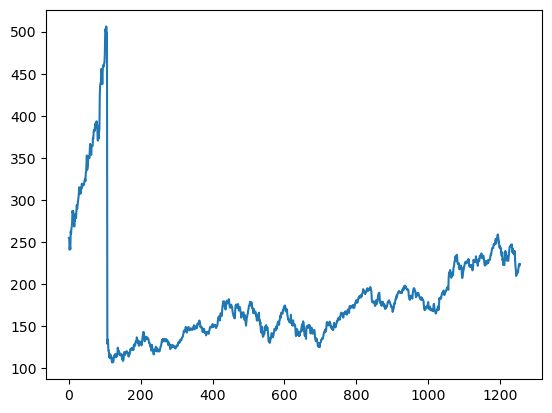

In [21]:
import matplotlib.pyplot as plt
plt.plot(df1); 

In [23]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler 
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [25]:
print(df1)

[[0.37061991]
 [0.36931747]
 [0.33580463]
 ...
 [0.29282405]
 [0.28726362]
 [0.29307451]]


In [27]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [29]:
training_size,test_size

(816, 440)

In [37]:
train_data

array([[3.70619912e-01],
       [3.69317470e-01],
       [3.35804634e-01],
       [3.45873513e-01],
       [3.37056982e-01],
       [3.89805886e-01],
       [3.82191609e-01],
       [3.98822793e-01],
       [4.03631810e-01],
       [4.16806512e-01],
       [4.51371321e-01],
       [4.44809017e-01],
       [4.50469631e-01],
       [4.40726362e-01],
       [4.26023795e-01],
       [4.04583594e-01],
       [4.23944897e-01],
       [4.21264872e-01],
       [4.41152160e-01],
       [4.41653100e-01],
       [4.30156544e-01],
       [4.53074515e-01],
       [4.68278021e-01],
       [4.56430808e-01],
       [4.66675016e-01],
       [4.77695679e-01],
       [4.85385097e-01],
       [4.93174703e-01],
       [5.09179712e-01],
       [5.21402630e-01],
       [5.12385723e-01],
       [5.02968065e-01],
       [5.07701941e-01],
       [5.03118347e-01],
       [5.21277395e-01],
       [5.16718848e-01],
       [5.31972448e-01],
       [5.26011271e-01],
       [5.31120852e-01],
       [5.25710708e-01],


In [41]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [43]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [45]:
print(X_train.shape), print(y_train.shape)

(715, 100)
(715,)


(None, None)

In [47]:
print(X_test.shape), print(ytest.shape)

(339, 100)
(339,)


(None, None)

In [49]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [51]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [53]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 637ms/step - loss: 0.0101 - val_loss: 0.0222
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 436ms/step - loss: 0.0091 - val_loss: 0.0033
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 480ms/step - loss: 0.0071 - val_loss: 0.0123
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 435ms/step - loss: 0.0049 - val_loss: 0.0040
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step - loss: 0.0053 - val_loss: 0.0062
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 401ms/step - loss: 0.0044 - val_loss: 0.0047
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 528ms/step - loss: 0.0032 - val_loss: 0.0046
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - loss: 0.0038 - val_loss: 0.0022
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 476ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - loss: 0.0047 - val_loss: 0.0025
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━

In [60]:
tf.__version__

'2.16.2'

In [61]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [62]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [63]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

153.7157340656317

In [64]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

207.61264315048683

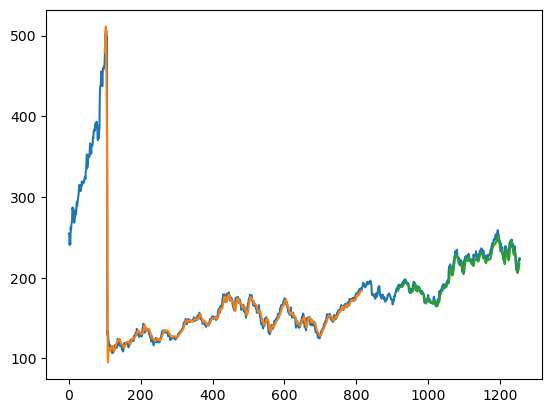

In [65]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [66]:
len(test_data)

440

In [67]:
x_input=test_data[341:].reshape(1,-1)
x_input.shape


(1, 99)

In [77]:
import torch

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found.")


No GPU found.


In [79]:
!system_profiler SPDisplaysDataType | grep "Chipset Model"

      Chipset Model: Intel HD Graphics 6000
